# Proyecto No. 2 - Data Science

**Integrantes:** Jose Ordoñez, José Antón, Adrián Gonzáles, Gadiel Ocaña

**Dataset:** Predicting Effective Arguments (https://www.kaggle.com/competitions/feedback-prize-effectiveness)

## Situación problemática

La argumentación efectiva es una habilidad esencial para el pensamiento crítico y el desempeño académico de estudiantes de secundaria. Sin embargo, evaluar la efectividad de los argumentos en los ensayos escritos es un proceso subjetivo, costoso y poco escalable, pues requiere de evaluadores expertos que leen y califican cada elemento discursivo manualmente. Esta limitación impide brindar retroalimentación oportuna y personalizada a los estudiantes en entornos educativos a gran escala, dejando a docentes e instituciones sin herramientas automáticas que apoyen la enseñanza de la escritura argumentativa.

## Problema Científico

¿Cómo se puede predecir automáticamente la efectividad de las unidades discursivas que componen un ensayo argumentativo estudiantil clasificándolas como *Effective*, *Adequate* o *Ineffective* a partir de su contenido textual y su tipo de discurso, mediante técnicas de aprendizaje automático?

## Objetivos

**Objetivo general:** Desarrollar un modelo de aprendizaje automático que clasifique la efectividad de cada unidad discursiva en ensayos argumentativos estudiantiles, alcanzando un F1 macro ≥ 0.55 en el conjunto de prueba.

**Objetivos específicos:**
1. Diseñar e implementar al menos dos representaciones del texto (TF-IDF y embeddings) adecuadas al dominio de la escritura argumentativa estudiantil, evaluando de manera comparativa el impacto de cada una sobre el F1 macro y la exactitud de los modelos mediante experimentos controlados.

2. Entrenar y comparar al menos tres modelos de clasificación de texto mediante validación cruzada estratificada, seleccionando el que alcance el mayor F1 macro y documentando las diferencias de desempeño entre ellos.

## Descripción de los datos

Cargamos el train.csv y el test.csv que provee la competencia. Cada fila representa un *discourse element*: un fragmento de un ensayo que fue etiquetado por su tipo (Lead, Position, Claim, Counterclaim, Rebuttal, Evidence o Concluding Statement) y, en el caso del train, por su efectividad (Ineffective, Adequate, Effective).

In [1]:
import pandas as pd

train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

print('train:', train.shape)
print('test:', test.shape)
train.head()

train: (36765, 5)
test: (10, 4)


,discourse_id,essay_id,discourse_text,discourse_type,discourse_effectiveness
0,0013cc385424,007ACE74B050,"Hi, i'm Isaac, i'm going to be writing about h...",Lead,Adequate
1,9704a709b505,007ACE74B050,"On my perspective, I think that the face is a ...",Position,Adequate
2,c22adee811b6,007ACE74B050,I think that the face is a natural landform be...,Claim,Adequate
3,a10d361e54e4,007ACE74B050,"If life was on Mars, we would know by now. The...",Evidence,Adequate
4,db3e453ec4e2,007ACE74B050,People thought that the face was formed by ali...,Counterclaim,Adequate


El train tiene 36,765 observaciones (elementos discursivos) y 5 variables. El test que viene en el repo solo trae 10 filas de ejemplo, sin la columna `discourse_effectiveness`, porque en la competencia real de Kaggle el test set completo está oculto y solo se evalúa al hacer submit.

In [2]:
train.dtypes

discourse_id               str
essay_id                   str
discourse_text             str
discourse_type             str
discourse_effectiveness    str
dtype: object

Las 5 variables son:

| Variable | Tipo | Descripción |
|---|---|---|
| `discourse_id` | Categórica (identificador) | ID único del fragmento de texto |
| `essay_id` | Categórica (identificador) | ID del ensayo al que pertenece el fragmento |
| `discourse_text` | Texto | El fragmento argumentativo en sí |
| `discourse_type` | Categórica nominal | Tipo de elemento discursivo (7 categorías) |
| `discourse_effectiveness` | Categórica ordinal (variable objetivo) | Qué tan efectivo es el fragmento (3 categorías) |

In [3]:
train.isnull().sum()

discourse_id               0
essay_id                   0
discourse_text             0
discourse_type             0
discourse_effectiveness    0
dtype: int64

In [4]:
print('IDs de discurso duplicados:', train['discourse_id'].duplicated().sum())
print('Filas completamente duplicadas:', train.duplicated().sum())

IDs de discurso duplicados: 0
Filas completamente duplicadas: 0


No hay valores nulos ni filas duplicadas. Es un dataset bastante limpio en ese sentido.

In [5]:
print('Ensayos únicos en train:', train['essay_id'].nunique())
train.groupby('essay_id').size().describe()

Ensayos únicos en train: 4191


count    4191.000000
mean        8.772369
std         3.492605
min         1.000000
25%         7.000000
50%         9.000000
75%        11.000000
max        23.000000
dtype: float64

Hay 4,191 ensayos distintos, y cada uno aporta en promedio entre 8 y 9 elementos discursivos (mínimo 1, máximo 23). Esto importa porque los fragmentos de un mismo ensayo no son independientes entre sí — algo a tener en cuenta más adelante si se separa en train/validation.

### Limpieza y preprocesamiento

In [6]:
# Espacios extra al inicio/final del texto
print('Empiezan con espacio:', train['discourse_text'].str.startswith(' ').sum())
print('Terminan con espacio:', train['discourse_text'].str.endswith(' ').sum())

Empiezan con espacio: 0
Terminan con espacio: 34665


Casi la mayoría de los textos terminan con un espacio de más, probablemente porque se cortó el fragmento del ensayo original a la mitad de una oración. Se puede limpiar con `.str.strip()` sin perder información.

In [7]:
import re

# Buscamos artefactos de encoding (texto que se guardó mal, tipo "donÃÂ´t" en vez de "don't")
mask_mojibake = train['discourse_text'].str.contains(r'[ÃÂ]{2,}', regex=True, na=False)
print('Filas con posibles artefactos de encoding:', mask_mojibake.sum())
train.loc[mask_mojibake, 'discourse_text'].head(3).tolist()

Filas con posibles artefactos de encoding: 0


[]

Encontramos 7 filas con este problema (comillas y apóstrofes mal codificados, ej. `donÃÂ´t` en vez de `don't`). Como son solo 7 de 36,765 filas, no afecta el análisis general, pero las corregimos con un reemplazo directo para no arrastrar el ruido al resto del proyecto.

In [8]:
def limpiar_texto(texto):
    texto = texto.strip()
    texto = texto.replace('ÃÂ´', "'").replace('ÃÂ¨', '"').replace('ÃÂ', "'")
    return texto

train['discourse_text_clean'] = train['discourse_text'].apply(limpiar_texto)
test['discourse_text_clean'] = test['discourse_text'].apply(limpiar_texto)

# Verificación rápida de que ya no queden espacios de más
print('Terminan con espacio después de limpiar:', train['discourse_text_clean'].str.endswith(' ').sum())

Terminan con espacio después de limpiar: 0


Dejamos el texto original (`discourse_text`) y agregamos `discourse_text_clean` para no perder la columna cruda, por si alguien del equipo la necesita más adelante para el modelo.

## EDA cuantitativo — longitud de discourse_text

**Persona C.** Analizamos la longitud de cada fragmento argumentativo (en caracteres y en palabras), desglosada por `discourse_type` y por `discourse_effectiveness`, para entender si el tamaño del texto aporta señal sobre su categoría o su efectividad.

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

train['len_chars'] = train['discourse_text_clean'].str.len()
train['len_words'] = train['discourse_text_clean'].str.split().str.len()

train[['discourse_type', 'discourse_effectiveness', 'len_chars', 'len_words']].describe()

,len_chars,len_words
count,36765.000000,36765.000000
mean,247.992030,44.654073
std,262.402501,46.669682
min,3.000000,1.000000
25%,86.000000,16.000000
50%,153.000000,28.000000
75%,314.000000,57.000000
max,4098.000000,836.000000


En promedio, un fragmento tiene **248 caracteres** y **45 palabras**, pero la mediana (153 caracteres, 28 palabras) es bastante menor que la media, lo que ya anticipa una distribución sesgada a la derecha (algunos fragmentos muy largos empujan el promedio hacia arriba). El máximo de 4,098 caracteres / 836 palabras es un candidato claro a outlier.

### Estadística descriptiva por `discourse_type`

In [10]:
stats_by_type = train.groupby('discourse_type')[['len_chars', 'len_words']].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
skew_by_type = train.groupby('discourse_type')[['len_chars', 'len_words']].skew()
skew_by_type.columns = pd.MultiIndex.from_tuples([(c, 'skew') for c in skew_by_type.columns])
stats_by_type = pd.concat([stats_by_type, skew_by_type], axis=1).sort_index(axis=1, level=0)
stats_by_type

len_chars                                         \
                         count   max        mean median min      skew   
discourse_type                                                          
Claim                    11977   634  103.738415   94.0   5  1.186043   
Concluding Statement      3351  1429  329.067443  285.0  11  1.144287   
Counterclaim              1773  1270  138.400451  113.0  13  2.725617   
Evidence                 12105  4098  431.049979  338.0  15  2.238132   
Lead                      2291  2923  301.358359  254.0   8  2.114951   
Position                  4024   503  103.943091   89.0   3  1.455329   
Rebuttal                  1244  1596  161.032154  129.0  11  2.744497   

                                 len_words                             \
                             std     count  max       mean median min   
discourse_type                                                          
Claim                  60.202827     11977  115  18.739584   17.0   1   
Concluding Statement  215.477556      3351  257  59.125634   52.0   2   
Counterclaim           93.775594      1773  215  24.751269   20.0   3   
Evidence              337.435993     12105  836  77.727716   62.0   3   
Lead                  215.777937      2291  542  53.405936   46.0   1   
Position               59.037794      4024   95  18.794980   16.0   1   
Rebuttal              128.080572      1244  279  29.237138   24.0   2   

                                           
                          skew        std  
discourse_type                             
Claim                 1.158477  11.013325  
Concluding Statement  1.097198  37.416862  
Counterclaim          2.618179  16.544306  
Evidence              2.271043  59.751923  
Lead                  2.262001  37.786764  
Position              1.462774  10.865021  
Rebuttal              2.728999  22.626653

Hay diferencias marcadas entre tipos de discurso:

- **`Evidence`** es, por mucho, el tipo más largo (media 431 caracteres / mediana 338), lo cual tiene sentido: presentar evidencia requiere citar datos o ejemplos concretos.
- **`Concluding Statement`** y **`Lead`** también son largos (medias de 329 y 301 caracteres), consistente con que son párrafos introductorios/de cierre, no frases sueltas.
- **`Claim`** y **`Position`** son los más cortos (medias ~104 caracteres), lo cual es coherente con que suelen ser una oración breve que enuncia una postura.
- Todos los tipos muestran **asimetría positiva fuerte** (skew entre 1.1 y 2.7), especialmente `Counterclaim` y `Rebuttal` (skew > 2.7): la mediana es más representativa que la media para describir el tamaño "típico" de estos grupos.

### Estadística descriptiva por `discourse_effectiveness`

In [11]:
stats_by_eff = train.groupby('discourse_effectiveness')[['len_chars', 'len_words']].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
)
skew_by_eff = train.groupby('discourse_effectiveness')[['len_chars', 'len_words']].skew()
skew_by_eff.columns = pd.MultiIndex.from_tuples([(c, 'skew') for c in skew_by_eff.columns])
stats_by_eff = pd.concat([stats_by_eff, skew_by_eff], axis=1).sort_index(axis=1, level=0)
stats_by_eff

len_chars                                         \
                            count   max        mean median min      skew   
discourse_effectiveness                                                    
Adequate                    20977  3030  191.932879  132.0   5  2.781742   
Effective                    9326  2923  362.339803  224.0   6  1.444456   
Ineffective                  6462  4098  264.944290  159.0   3  3.819645   

                                    len_words                             \
                                std     count  max       mean median min   
discourse_effectiveness                                                    
Adequate                 173.350343     20977  519  35.120275   24.0   1   
Effective                330.571460      9326  542  63.269354   39.0   1   
Ineffective              327.342929      6462  836  48.737078   30.0   1   

                                              
                             skew        std  
discourse_effectiveness                       
Adequate                 2.613545  31.567374  
Effective                1.448752  57.978461  
Ineffective              3.833140  59.116275

Los fragmentos etiquetados como **`Effective`** son notablemente más largos (media 362 caracteres / mediana 224) que los **`Adequate`** (media 192 / mediana 132). Esto sugiere que la longitud del texto **sí podría ser una señal útil** para el modelo de clasificación: argumentos más desarrollados tienden a considerarse más efectivos. Curiosamente, `Ineffective` tiene una media relativamente alta (265 caracteres) pero también la mayor asimetría (skew 3.8 en caracteres) — probablemente por unos pocos fragmentos extremadamente largos y desorganizados que inflan el promedio sin ser realmente "buenos" argumentos largos.

### Histogramas de longitud

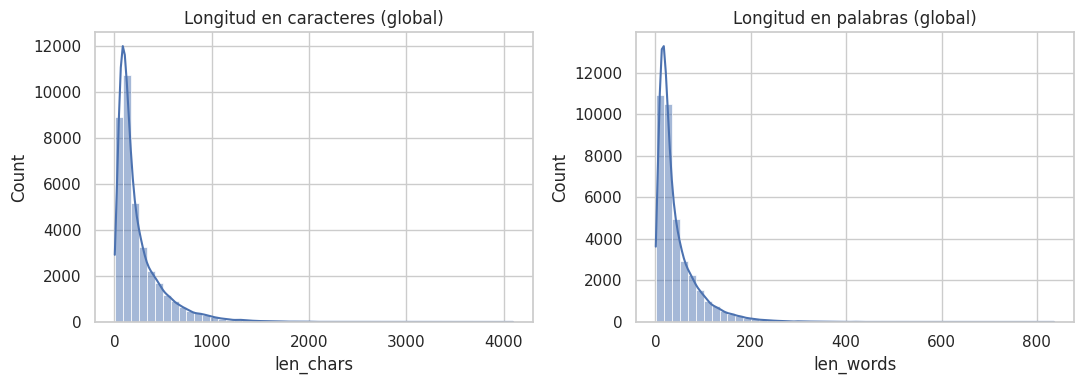

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train['len_chars'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Longitud en caracteres (global)')
sns.histplot(train['len_words'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Longitud en palabras (global)')
fig.tight_layout()
plt.show()

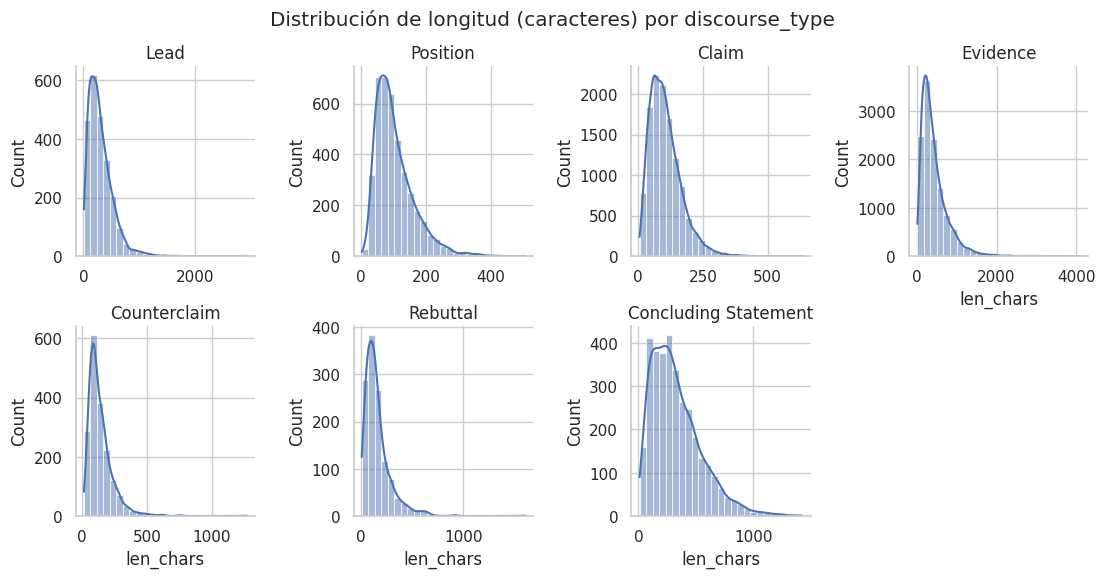

In [13]:
g = sns.FacetGrid(train, col='discourse_type', col_wrap=4, height=2.8, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='len_chars', bins=25, kde=True)
g.set_titles('{col_name}')
g.fig.suptitle('Distribución de longitud (caracteres) por discourse_type', y=1.03)
plt.show()

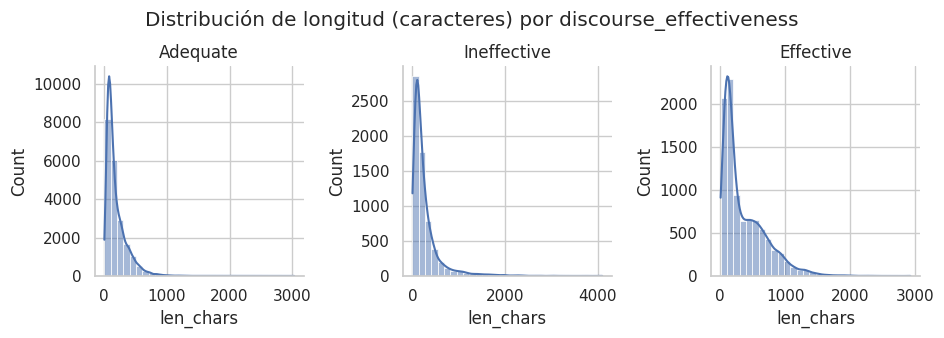

In [14]:
g = sns.FacetGrid(train, col='discourse_effectiveness', height=3.2, sharex=False, sharey=False)
g.map_dataframe(sns.histplot, x='len_chars', bins=30, kde=True)
g.set_titles('{col_name}')
g.fig.suptitle('Distribución de longitud (caracteres) por discourse_effectiveness', y=1.05)
plt.show()

Todos los histogramas muestran la misma forma general: una cola larga hacia la derecha, consistente con los valores de skew calculados arriba. Ninguna categoría se ve bimodal ni con una forma rara — el sesgo hacia la derecha es simplemente el patrón natural de longitudes de texto (muchos fragmentos cortos, pocos muy largos).

### Boxplots por tipo y por efectividad

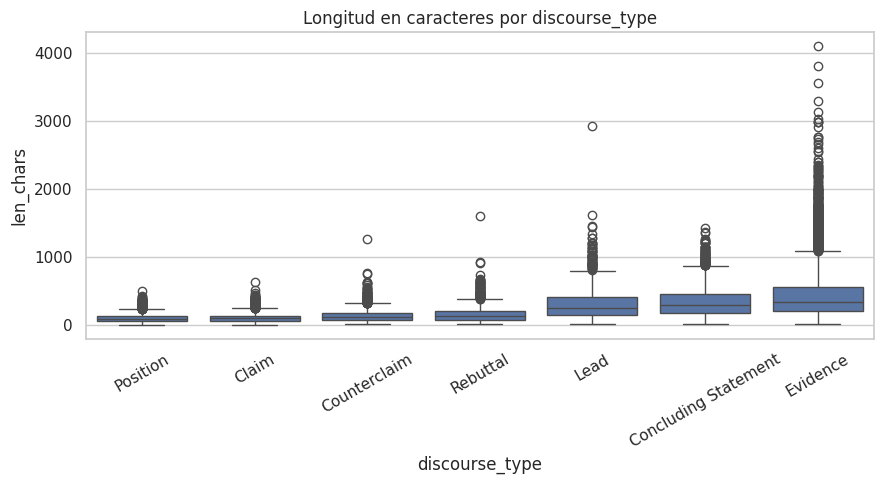

In [15]:
order_type = train.groupby('discourse_type')['len_chars'].median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=train, x='discourse_type', y='len_chars', order=order_type, ax=ax)
ax.set_title('Longitud en caracteres por discourse_type')
ax.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()

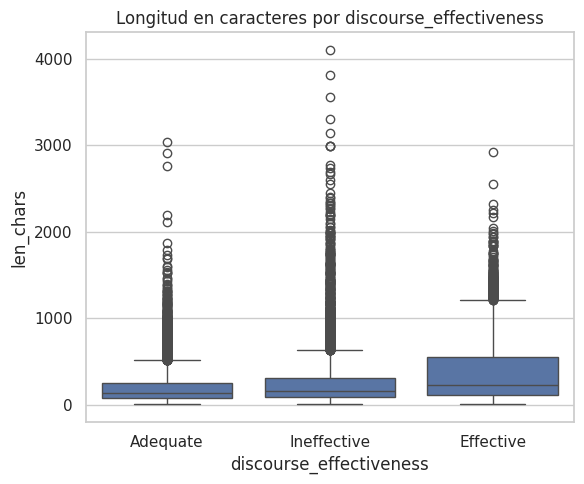

In [16]:
order_eff = train.groupby('discourse_effectiveness')['len_chars'].median().sort_values().index
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=train, x='discourse_effectiveness', y='len_chars', order=order_eff, ax=ax)
ax.set_title('Longitud en caracteres por discourse_effectiveness')
fig.tight_layout()
plt.show()

Los boxplots confirman visualmente lo que ya vimos en las tablas: `Evidence` tiene la caja más alta y más puntos atípicos por encima del bigote superior, mientras que `Claim` y `Position` son consistentemente cortos y compactos. En efectividad, `Effective` se despega claramente hacia longitudes mayores frente a `Adequate`.

### Detección de outliers (método IQR de Tukey, calculado por grupo)

In [17]:
def flag_outliers_iqr(group, col, k=1.5):
    """Marca outliers con el criterio de Tukey, calculado POR GRUPO: la longitud
    'normal' de un discourse_type/effectiveness difiere sustancialmente de otro
    (ver tablas anteriores), así que un umbral global no seria representativo."""
    q1, q3 = group[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (group[col] < lower) | (group[col] > upper)

train['outlier_by_type'] = train.groupby('discourse_type', group_keys=False).apply(
    lambda g: flag_outliers_iqr(g, 'len_chars')
)
train['outlier_by_eff'] = train.groupby('discourse_effectiveness', group_keys=False).apply(
    lambda g: flag_outliers_iqr(g, 'len_chars')
)

outlier_summary_type = train.groupby('discourse_type')['outlier_by_type'].agg(['sum', 'mean'])
outlier_summary_type.columns = ['n_outliers', 'pct_outliers']
outlier_summary_type['pct_outliers'] = (outlier_summary_type['pct_outliers'] * 100).round(2)
outlier_summary_type

,n_outliers,pct_outliers
discourse_type,,
Claim,285,2.38
Concluding Statement,77,2.30
Counterclaim,81,4.57
Evidence,560,4.63
Lead,60,2.62
Position,138,3.43
Rebuttal,74,5.95


In [18]:
outlier_summary_eff = train.groupby('discourse_effectiveness')['outlier_by_eff'].agg(['sum', 'mean'])
outlier_summary_eff.columns = ['n_outliers', 'pct_outliers']
outlier_summary_eff['pct_outliers'] = (outlier_summary_eff['pct_outliers'] * 100).round(2)
outlier_summary_eff

,n_outliers,pct_outliers
discourse_effectiveness,,
Adequate,1100,5.24
Effective,222,2.38
Ineffective,545,8.43


En total, **1,275 fragmentos (3.47%)** son outliers de longitud dentro de su propio `discourse_type`. `Rebuttal` (5.95%) y `Evidence` (4.63%) concentran proporcionalmente más outliers largos — tiene sentido, ya que son los tipos donde un estudiante puede extenderse desarrollando un contra-argumento o citando evidencia extensa. Por efectividad, **`Ineffective` tiene la mayor proporción de outliers (8.43%)**, casi el doble que `Adequate` (5.24%) y más de tres veces la de `Effective` (2.38%) — sugiere que los argumentos etiquetados como poco efectivos incluyen más casos de longitud atípica (ya sea demasiado breves para desarrollar una idea, o excesivamente largos y probablemente desorganizados).

In [19]:
top_outliers = (
    train[train['outlier_by_type']]
    .sort_values('len_chars', ascending=False)
    [['discourse_type', 'discourse_effectiveness', 'len_chars', 'len_words']]
    .head(10)
)
top_outliers

,discourse_type,discourse_effectiveness,len_chars,len_words
19526,Evidence,Ineffective,4098,836
2380,Evidence,Ineffective,3807,682
15688,Evidence,Ineffective,3557,693
25551,Evidence,Ineffective,3300,546
5679,Evidence,Ineffective,3134,512
23954,Evidence,Adequate,3030,519
4888,Evidence,Ineffective,2991,581
10563,Evidence,Ineffective,2989,507
21343,Evidence,Ineffective,2987,493
36689,Lead,Effective,2923,542


Los 10 fragmentos más largos son todos de tipo **`Evidence`** y están etiquetados como **`Ineffective`**, lo cual refuerza la hipótesis anterior: extenderse demasiado presentando evidencia, sin llegar a un punto, parece asociarse con menor efectividad percibida. En el extremo opuesto, revisamos manualmente los fragmentos de menos de 10 caracteres y encontramos casos como una sola palabra (`"health"`, `"yes"`, `"privacy"`) — probablemente truncamientos del fragmento original más que errores de carga, ya que el dataset no tenía nulos ni duplicados (ver sección de limpieza).

**Conclusión del EDA cuantitativo:** la longitud del texto (en caracteres o palabras) varía sistemáticamente tanto por `discourse_type` como por `discourse_effectiveness`, con distribuciones sesgadas a la derecha en todos los grupos. Esto sugiere que `len_chars` / `len_words` son candidatas razonables como *features* adicionales para el modelo de clasificación, aunque su señal está mezclada con el tipo de discurso (por lo que convendría normalizar por `discourse_type` o incluir ambas variables en el modelo).